In [1]:
import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree
import jaxls
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

## Setup

In [2]:
# 3D double-integrator drone.
m = 1.0
dt = 0.1

A = jnp.block([[jnp.eye(3), dt * jnp.eye(3)], [jnp.zeros((3, 3)), jnp.eye(3)]])
B = jnp.concatenate([jnp.zeros((3, 3)), (dt / m) * jnp.eye(3)], axis=0)
Q = dt * 0.25 * jnp.eye(6)  # process noise covariance

def f(x, u):
    return A @ x + B @ u

### Reference trajectory

In [ ]:
horizon = 100
scale   = 3.0

# Trajectory: figure-eight at constant altitude.
t_arr = jnp.linspace(0, 2 * jnp.pi, horizon + 1)
pos_ref = scale * jnp.stack([
    jnp.sin(t_arr),
    jnp.sin(2 * t_arr) / 2,
    jnp.ones_like(t_arr),
], axis=1)

# Finite-difference reference velocity (repeat last sample to match length).
vel_ref = jnp.diff(pos_ref, axis=0) / dt
vel_ref = jnp.concatenate([vel_ref, vel_ref[-1:]], axis=0)

X_ref = jnp.concatenate([pos_ref, vel_ref], axis=1)

mu0    = X_ref[0]
Sigma0 = 0.01 * jnp.eye(6)
x0     = jax.random.multivariate_normal(jax.random.PRNGKey(0), mu0, Sigma0)

### Landmarks and range sensor

In [13]:
# Ten landmarks in a ring around the trajectory (good geometry for trilateration).
N_landmarks = 10
angles = jnp.linspace(0, 2 * jnp.pi, N_landmarks, endpoint=False)
lm_xy  = 5.0 * jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1)
lm_z   = jnp.ones((N_landmarks, 1))
L_true = jnp.concatenate([lm_xy, lm_z], axis=1)  # (N_landmarks, 3)

sigma_r = 0.2  # range noise std (m)

### Simulating data

In [25]:
key = jax.random.PRNGKey(42)
k_proc, k_meas = jax.random.split(key)
W = jax.random.multivariate_normal(k_proc, jnp.zeros(6), Q, (horizon,))
V = jax.random.normal(k_meas, (horizon + 1, N_landmarks)) * sigma_r

# PD tracking controller.
Kp = 10.0 * jnp.eye(3)
Kd =  5.0 * jnp.eye(3)

def measure(pos, noise):
    return jnp.linalg.norm(pos[None, :] - L_true, axis=1) + noise

xs = [x0]
us = []
ds = [measure(x0[:3], V[0])]

for t in range(horizon):
    pos, vel = xs[-1][:3], xs[-1][3:]
    u = Kp @ (pos_ref[t + 1] - pos) + Kd @ (vel_ref[t + 1] - vel)
    x_next = f(xs[-1], u) + W[t]
    us.append(u)
    xs.append(x_next)
    ds.append(measure(x_next[:3], V[t + 1]))

X = jnp.stack(xs)  # (T+1, 6) ground-truth states
U = jnp.stack(us)  # (T,   3) controls
D = jnp.stack(ds)  # (T+1, N_landmarks) range measurements

## Factor graph

In [ ]:
# Precompute square roots of inverse covariances for scaling the residuals.
Q_inv_sqrt      = jnp.real(jax.scipy.linalg.sqrtm(jnp.linalg.inv(Q)))
Sigma0_inv_sqrt = jnp.real(jax.scipy.linalg.sqrtm(jnp.linalg.inv(Sigma0)))


class StateVar(jaxls.Var[jax.Array], default_factory=lambda: jnp.zeros(6)):
    """Drone state [px, py, pz, vx, vy, vz]."""

class LandmarkVar(jaxls.Var[jax.Array], default_factory=lambda: jnp.zeros(3)):
    """Landmark position [x, y, z]."""


@jaxls.Cost.factory
def prior_cost(vals: jaxls.VarValues, state: StateVar) -> jax.Array:
    return Sigma0_inv_sqrt @ (vals[state] - mu0)


@jaxls.Cost.factory
def dynamics_cost(
    vals: jaxls.VarValues,
    state_curr: StateVar,
    state_next: StateVar,
    u: jax.Array,
) -> jax.Array:
    return Q_inv_sqrt @ (vals[state_next] - f(vals[state_curr], u))


@jaxls.Cost.factory
def range_cost(
    vals: jaxls.VarValues,
    state: StateVar,
    landmark: LandmarkVar,
    d: jax.Array,
) -> jax.Array:
    pos = vals[state][:3]
    return ((jnp.linalg.norm(pos - vals[landmark]) - d) / sigma_r).reshape(1)

### Building the problem

In [27]:
# Range factors connect every state to every landmark.
state_ids = jnp.repeat(jnp.arange(horizon + 1), N_landmarks)
lm_ids    = jnp.tile(jnp.arange(N_landmarks), horizon + 1)

costs = [
    prior_cost(StateVar(id=0)),
    dynamics_cost(
        StateVar(id=jnp.arange(horizon)),
        StateVar(id=jnp.arange(1, horizon + 1)),
        u=U,
    ),
    range_cost(
        StateVar(id=state_ids),
        LandmarkVar(id=lm_ids),
        D.reshape(-1),
    ),
]

drone_state_vars = StateVar(id=jnp.arange(horizon + 1))
landmark_vars    = LandmarkVar(id=jnp.arange(N_landmarks))

# Initial guess: drone sits at the prior mean, landmarks scattered at the
# right rough scale (range-only is non-convex; bad init -> bad local minima).
rough_range = float(jnp.mean(D))
lm_init = jnp.concatenate([
    rough_range * jax.random.normal(jax.random.PRNGKey(0), (N_landmarks, 2)),
    jnp.ones((N_landmarks, 1)),
], axis=1)

initial_guess = jaxls.VarValues.make([
    drone_state_vars.with_value(jnp.tile(mu0, (horizon + 1, 1))),
    landmark_vars.with_value(lm_init),
])

problem = jaxls.LeastSquaresProblem(costs, [drone_state_vars, landmark_vars]).analyze()

2026-04-09 14:12:19.251 | INFO     | jaxls._py310._problem:analyze:121 - Building optimization problem with 1111 terms and 111 variables: 1111 costs, 0 eq_zero, 0 leq_zero, 0 geq_zero
2026-04-09 14:12:19.270 | INFO     | jaxls._py310._problem:analyze:229 - Vectorizing group with 1 costs, 1 variables each: prior_cost
2026-04-09 14:12:19.299 | INFO     | jaxls._py310._problem:analyze:229 - Vectorizing group with 100 costs, 2 variables each: dynamics_cost
2026-04-09 14:12:19.323 | INFO     | jaxls._py310._problem:analyze:229 - Vectorizing group with 1010 costs, 2 variables each: range_cost


### Sparsity of the residual Jacobian

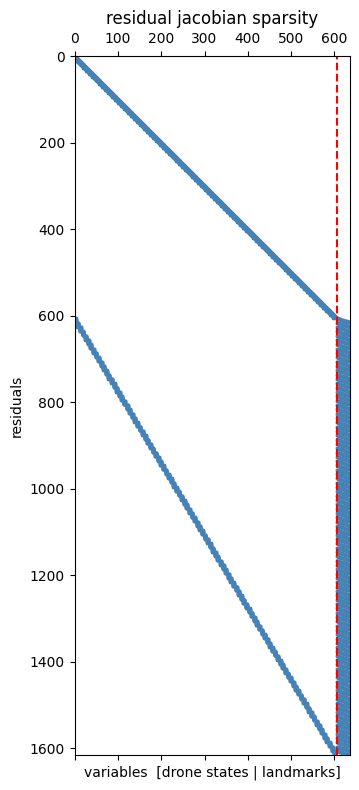

In [29]:
# Differentiate the (vectorized) residual w.r.t. variable values to recover
# the factor-graph Jacobian directly from jaxls. The pytree-shaped output has
# one block per variable type, which we reshape and concatenate ourselves.
def residual_vector(vals_from_type):
    return problem.compute_residual_vector(jaxls.VarValues(
        vals_from_type=vals_from_type,
        ids_from_type=initial_guess.ids_from_type,
    ))

J_blocks = jax.jacobian(residual_vector)(initial_guess.vals_from_type)
J_state  = onp.asarray(J_blocks[StateVar]).reshape(-1, (horizon + 1) * 6)
J_lm     = onp.asarray(J_blocks[LandmarkVar]).reshape(-1, N_landmarks * 3)
J        = onp.concatenate([J_state, J_lm], axis=1)

n_state_cols = (horizon + 1) * 6

fig, ax = plt.subplots(figsize=(12, 8))
ax.spy(onp.abs(J) > 1e-10, markersize=1.5, color='steelblue')
ax.axvline(x=n_state_cols - 0.5, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('variables  [drone states | landmarks]')
ax.set_ylabel('residuals')
ax.set_title('residual jacobian sparsity')
plt.tight_layout()
plt.show()

### Solve

In [30]:
solution = problem.solve(initial_guess, linear_solver="cholmod")

cov_estimator  = problem.make_covariance_estimator(solution)
covariance_jit = jax.jit(cov_estimator.covariance)

X_smooth = onp.array(jnp.stack([solution[StateVar(id=t)]    for t in range(horizon + 1)]))
L_est    = onp.array(jnp.stack([solution[LandmarkVar(id=m)] for m in range(N_landmarks)]))

2026-04-09 14:12:32.454 | INFO     | jaxls._py310.utils:_log:23 -  step #0: cost=817523.7500 lambd=0.0005
2026-04-09 14:12:32.455 | INFO     | jaxls._py310.utils:_log:23 -      - prior_cost(1):  0.00000 (avg 0.00000)
2026-04-09 14:12:32.455 | INFO     | jaxls._py310.utils:_log:23 -      - dynamics_cost(100): 1082.99463 (avg 1.80499)
2026-04-09 14:12:32.456 | INFO     | jaxls._py310.utils:_log:23 -      - range_cost(1010): 816440.75000 (avg 808.35718)
2026-04-09 14:12:32.457 | INFO     | jaxls._py310.utils:_log:23 -      accepted=True ATb_norm=4.49e+04 cost_prev=817523.9375 cost_new=68285.2031
2026-04-09 14:12:32.461 | INFO     | jaxls._py310.utils:_log:23 -  step #1: cost=68285.1953 lambd=0.0003
2026-04-09 14:12:32.463 | INFO     | jaxls._py310.utils:_log:23 -      - prior_cost(1):  0.52044 (avg 0.08674)
2026-04-09 14:12:32.465 | INFO     | jaxls._py310.utils:_log:23 -      - dynamics_cost(100): 371.08948 (avg 0.61848)
2026-04-09 14:12:32.466 | INFO     | jaxls._py310.utils:_log:23 -  

## Results

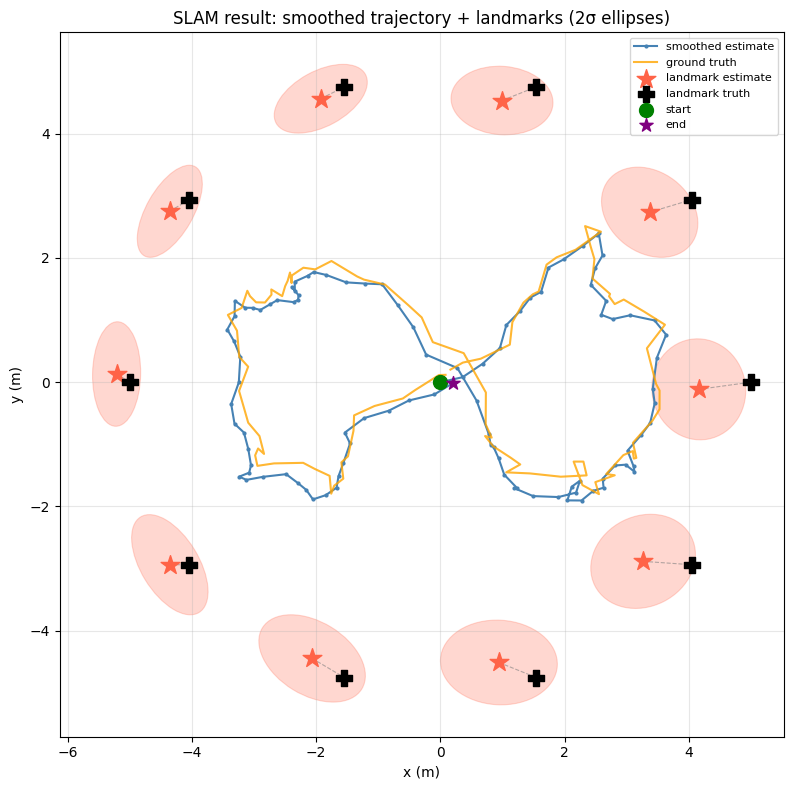

In [31]:
def cov_ellipse(mean_xy, cov_xy, n_std=2.0, **kwargs):
    """Matplotlib Ellipse patch for a 2D Gaussian."""
    eigvals, eigvecs = onp.linalg.eigh(cov_xy)
    eigvals = onp.maximum(eigvals, 0)
    angle   = onp.degrees(onp.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * onp.sqrt(eigvals)
    return Ellipse(xy=mean_xy, width=width, height=height, angle=angle, **kwargs)

POS = [0, 1]

covs_drone_xy = [
    onp.array(covariance_jit(StateVar(id=t), StateVar(id=t)))[onp.ix_(POS, POS)]
    for t in range(horizon + 1)
]
covs_lm_xy = [
    onp.array(covariance_jit(LandmarkVar(id=m), LandmarkVar(id=m)))[:2, :2]
    for m in range(N_landmarks)
]

X_smooth_xy = X_smooth[:, POS]
L_est_xy    = L_est[:, :2]
L_true_xy   = onp.array(L_true)[:, :2]

fig, ax = plt.subplots(figsize=(10, 8))

for mean, C_xy in zip(L_est_xy, covs_lm_xy):
    ax.add_patch(cov_ellipse(mean, C_xy, n_std=2,
                             facecolor='tomato', edgecolor='tomato',
                             alpha=0.25, linewidth=0.8))

ax.plot(X_smooth_xy[:, 0], X_smooth_xy[:, 1],
        'o-', color='steelblue', markersize=2, linewidth=1.5,
        label='smoothed estimate', zorder=3)
ax.plot(X[:, 0], X[:, 1],
        '-', color='orange', linewidth=1.5, alpha=0.8,
        label='ground truth', zorder=4)

ax.scatter(L_est_xy[:, 0], L_est_xy[:, 1],
           marker='*', s=200, color='tomato', zorder=6, label='landmark estimate')
ax.scatter(L_true_xy[:, 0], L_true_xy[:, 1],
           marker='P', s=120, color='black', zorder=7, label='landmark truth')

# Connect each landmark estimate to its ground truth.
for j in range(N_landmarks):
    ax.plot([L_est_xy[j, 0], L_true_xy[j, 0]],
            [L_est_xy[j, 1], L_true_xy[j, 1]],
            '--', color='gray', linewidth=0.8, alpha=0.6)

ax.scatter(*X_smooth_xy[0],  s=100, color='green',  zorder=8, label='start')
ax.scatter(*X_smooth_xy[-1], s=100, color='purple', zorder=8, marker='*', label='end')

ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('SLAM result: smoothed trajectory + landmarks (2σ ellipses)')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

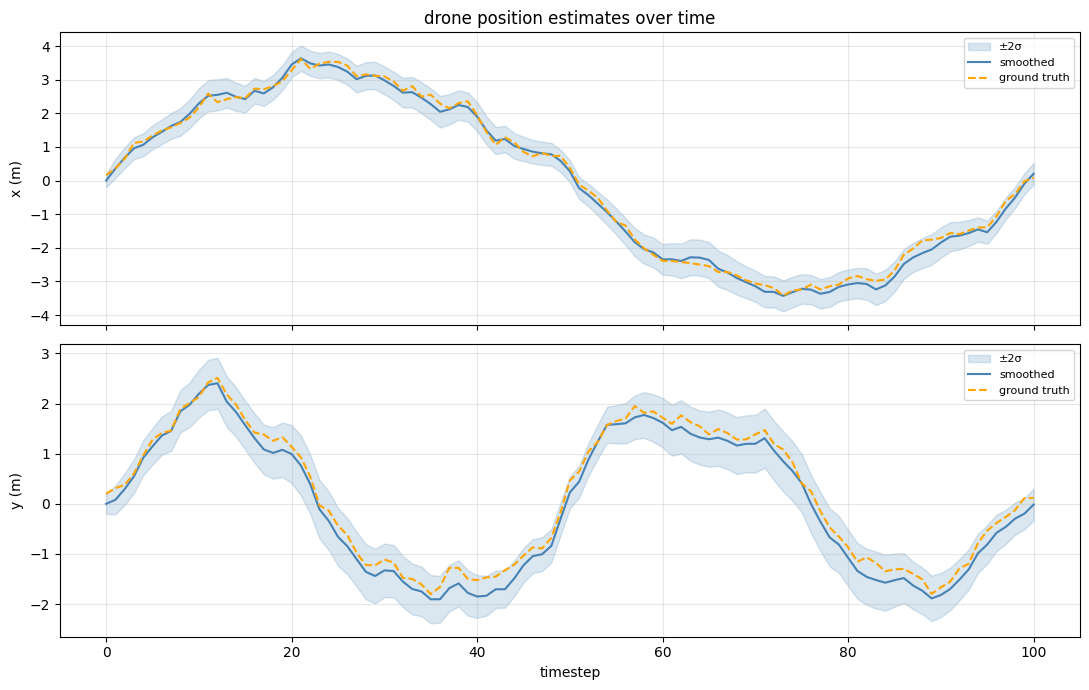

In [32]:
stds = onp.array([onp.sqrt(onp.maximum(onp.diag(C), 0)) for C in covs_drone_xy])

ts = onp.arange(horizon + 1)

fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for ax, est, gt, std, label in [
    (ax_x, X_smooth[:, 0], X[:, 0], stds[:, 0], 'x'),
    (ax_y, X_smooth[:, 1], X[:, 1], stds[:, 1], 'y'),
]:
    ax.fill_between(ts, est - 2 * std, est + 2 * std,
                    color='steelblue', alpha=0.2, label='±2σ')
    ax.plot(ts, est, color='steelblue', linewidth=1.5, label='smoothed')
    ax.plot(ts, gt,  color='orange',    linewidth=1.5, linestyle='--', label='ground truth')
    ax.set_ylabel(f'{label} (m)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

ax_x.set_title('drone position estimates over time')
ax_y.set_xlabel('timestep')
plt.tight_layout()
plt.show()